---
title: "Chapter 6: Hyperparameter Optimization"
---


::: {.callout-lo}
By the end of this chapter, you will be able to:

- Explain how hyperparameter selection differs from fitting model parameters.
- Tune a complete pipeline using `GridSearchCV` and `RandomizedSearchCV`.
- Choose search ranges and interpret cross-validation search results.
- Estimate the number of model fits required by a search.
- Explain optimization bias and distinguish the selected cross-validation score from a final test score.
- Identify evaluation workflows that reuse validation or test data in misleading ways.
:::


Changing a hyperparameter takes one line of code. Deciding what to change it to is harder. Should we let a decision tree grow deeper? Use more neighbours in $k$-NN? Which combination of `C` and `gamma` should we use for an RBF SVM? Try a different model altogether? We already know how to compare a few choices using for loops and cross-validation, but the possibilities multiply quickly.

In this chapter, we will turn those comparisons into a systematic search, starting with a familiar task: choosing a tree's depth. Along the way, we will encounter a puzzle: **if we try more settings and find a higher validation score, have we necessarily found a better model?** The answer will help us decide both how to search and how much to trust what we find.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binom, loguniform, randint
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

DATA_DIR = Path("data")
CV = 5


## Why tune hyperparameters?

Let's start with a task we already know how to carry out: choosing a decision tree's `max_depth` using cross-validation. A shallow tree may underfit, while a deeper tree may fit quirks of the training examples. We want a depth that works well on unseen examples, so we compare validation scores rather than choosing the highest training score.

Let's bring back the [Spotify Song Attributes](https://www.kaggle.com/datasets/geomack/spotifyclassification) dataset. Our task is to predict whether a listener will like a song. This dataset contains numerical audio features, categorical features, and song titles. Its binary target records whether the listener liked a song (`1`) or did not (`0`). We will combine preprocessing and a tree in a pipeline, using the tools from Chapters 5 and 6.

First, we set aside the test set. All our model-selection decisions will use cross-validation on the training set.


In [2]:
spotify_df = pd.read_csv(DATA_DIR / "spotify.csv", index_col=0)
X = spotify_df.drop(columns=["target", "artist"])
y = spotify_df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y,
)
X_train.head()


,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,song_title
487,0.019300,0.352,248133,0.807,0.000006,0,0.0963,-7.781,1,0.1730,90.772,4.0,0.0459,Don't Die
215,0.030400,0.614,315000,0.838,0.000297,10,0.1660,-6.896,1,0.0280,127.971,4.0,0.5840,Come Save Me
1582,0.830000,0.534,238265,0.582,0.000000,2,0.1250,-6.220,1,0.0424,186.346,4.0,0.2890,No Le Digas Que Hacer
749,0.000076,0.597,343878,0.839,0.825000,7,0.5500,-6.964,1,0.0377,108.993,4.0,0.1990,Viol - Original Mix
587,0.040100,0.636,267147,0.702,0.000000,11,0.1050,-5.437,1,0.0743,125.998,4.0,0.4710,Hold Me Back


We scale the numerical features, one-hot encode the categorical features, pass through the binary `mode` feature, and represent song titles with `CountVectorizer`. Scaling is unnecessary for a tree, but lets us reuse this preprocessor with an SVM later. We omit artist identity in this example.

As in Chapter 5, the string `"song_title"` selects a one-dimensional collection of documents for `CountVectorizer`; the other transformers receive lists of columns. Keeping preprocessing inside the pipeline ensures that each fold learns its scaling statistics, categories, and vocabulary using only its training portion.


In [3]:
numeric_feats = [
    "acousticness", "danceability", "duration_ms", "energy", "instrumentalness",
    "liveness", "loudness", "speechiness", "tempo", "valence",
]
categorical_feats = ["time_signature", "key"]

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_feats),
    (OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ("passthrough", ["mode"]),
    (CountVectorizer(max_features=100, stop_words="english"), "song_title"),
)

baseline_scores = cross_val_score(
    DummyClassifier(strategy="most_frequent"), X_train, y_train,
    cv=CV, scoring="accuracy",
)
baseline_scores.mean()


np.float64(0.5058900448051074)

Now we try ten possible depths. For each depth, we build a pipeline, compute its mean cross-validation accuracy, and record the result. The only setting we change between candidates is `max_depth`.


In [4]:
depth_results = []
for depth in range(1, 20, 2):
    tree_pipe = make_pipeline(
        preprocessor, DecisionTreeClassifier(max_depth=depth, random_state=123),
    )
    scores = cross_val_score(
        tree_pipe, X_train, y_train, cv=CV, scoring="accuracy",
    )
    depth_results.append({"max_depth": depth, "mean_cv_score": scores.mean()})

depth_results = pd.DataFrame(depth_results)
depth_results.sort_values("mean_cv_score", ascending=False)


,max_depth,mean_cv_score
3,7,0.719143
1,3,0.718543
2,5,0.716055
5,11,0.704286
4,9,0.702408
6,13,0.686928
7,15,0.680722
8,17,0.679474
9,19,0.678253
0,1,0.647226


We choose the depth with the highest mean validation accuracy and refit its pipeline on all the training data. This is the same selection-and-refitting workflow we used in earlier chapters. We leave test evaluation until we have finished model development.


In [5]:
best_depth = int(depth_results.loc[depth_results["mean_cv_score"].idxmax(), "max_depth"])
selected_tree = make_pipeline(
    preprocessor, DecisionTreeClassifier(max_depth=best_depth, random_state=123),
)
selected_tree.fit(X_train, y_train)
print("Selected depth:", best_depth)


Selected depth: 7


We can summarize this workflow as shown in the picture below:

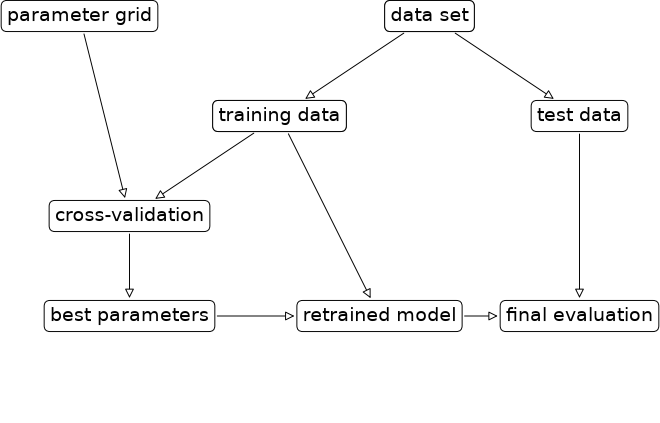

In [6]:
import mglearn

mglearn.plots.plot_grid_search_overview();


::: {.callout-note title="Why stop before test evaluation?"}
The complete workflow includes a final test-set evaluation. If we had finished choosing our model, we would now call `selected_tree.score(X_test, y_test)`. Here, we will continue exploring other models and hyperparameters, so we leave the test set untouched until those choices are complete. The code pauses at refitting; we will return to final evaluation at the end of the chapter.
:::


### From choosing a depth to choosing a pipeline

For one listener and one hyperparameter, the loop is manageable. It performs ten five-fold comparisons (50 pipeline fits) followed by one fit of the selected pipeline. The chosen depth is the best among those we tried according to cross-validation; it is not guaranteed to be the best possible depth on future data.

Choosing a tree's depth is only one of the decisions we face. We have already learned several model families: should we use a decision tree, $k$-nearest neighbours, an RBF SVM, or a linear model? Each comes with its own hyperparameters, such as `max_depth` for a tree or the number of neighbours for $k$-NN. Our preprocessing choices add more possibilities: for example, `CountVectorizer`'s `max_features` limits how many vocabulary terms we retain.

We can think of each combination of preprocessing choices, model family, and hyperparameter values as a **candidate pipeline**. Which candidate should we use for the task at hand? Our depth-search loop explored just ten candidates, keeping everything else fixed. Once we allow these other choices to vary, the number of candidates grows rapidly. Some hyperparameters, such as `C` and `gamma`, can take any positive real value, so we cannot exhaustively evaluate every possibility. A finite grid may be manageable, but it covers only the choices we put into it.

Hyperparameter optimization therefore involves deciding both **where to search** and **how to spend the computation available**. Automated methods help us evaluate candidates systematically, but we still need to define a useful search space.

::: {.callout-reflection}

<div class="callout-reflection-title">What if we needed to do this for 10,000 listeners?</div>

Imagine working at a music recommendation company (e.g., Spotify). You need to compare models and tune a separate song-preference pipeline for each of 10,000 listeners. Use five-fold cross-validation throughout, and initially count only the cross-validation fits, excluding final refits.

1. **Repeat the familiar search.** If you try the same ten tree depths for every listener, how many pipeline fits will you need in total?
2. **Add more choices.** For an RBF SVM, you want to try three vocabulary sizes, four values of `C`, and five values of `gamma`. How many candidate pipelines does this give per listener? How many cross-validation fits does that mean per listener and across all 10,000 listeners? If you run both the tree and SVM searches, what is the combined total?
3. **Translate fits into time.** Suppose each pipeline fit and its validation scoring take one second, and all runs happen sequentially. Roughly how many days would the combined search take?
4. **Decide what automation should do.** What would you want a search tool to record and handle for you? If it evaluates exactly the same candidates with the same folds as your loops, does automation alone reduce the number of fits? What could you change if the search exceeds your computational budget?
:::

::: {.callout-tip collapse="true" title="Discussion"}
1. The tree search requires $10 \times 5 \times 10{,}000 = 500{,}000$ cross-validation fits.
2. The SVM search has $3 \times 4 \times 5 = 60$ candidates per listener. That means 300 cross-validation fits per listener, or 3,000,000 across all listeners. Running both searches requires 3,500,000 cross-validation fits.
3. At one second per run, the combined search takes about $3{,}500{,}000 / 86{,}400 \approx 40.5$ days. This is a simplified estimate: actual run times vary with the data and settings, and parallel execution can reduce elapsed time.
4. A tool could record each candidate's model, preprocessing settings, scores, and run time, then select and refit a pipeline for each listener. It should apply the evaluation procedure consistently within each listener's search. Evaluating the same candidates and folds still requires the same number of fits. To reduce that number, we could try fewer values or sample a limited number of combinations, accepting that we may miss useful candidates. Model knowledge can guide those choices, but changing the range restricts what the search can discover.
:::

### Automating the search

We can still use our understanding of a model to suggest settings. For example, reducing `max_depth` when a tree is overfitting. Manual tuning can be reproducible when we record the settings, splits, and evaluation procedure. The problem is the growing amount of work needed to manage these experiments.

**Automated hyperparameter search** packages the repeated fitting, evaluation, selection, and refitting into a reusable procedure. We specify a **search space**, the candidate settings to explore, and an evaluation procedure. The search handles the bookkeeping that we wrote ourselves above.

`GridSearchCV` evaluates every specified combination, so it does not reduce the number of fits. However, these fits are independent and can run in parallel: setting `n_jobs=-1` lets the search use all available CPU cores, potentially reducing the elapsed time compared with the sequential loop we wrote above. We could also parallelize our own code, but the search tool handles this for us. `RandomizedSearchCV` supports parallel execution too, and also lets us limit the number of candidates evaluated. Both approaches still require sensible search ranges and careful use of held-out data.


## Automating the workflow with `GridSearchCV`

We will reuse the full preprocessor and the same training data, now with an RBF SVM so we can explore two interacting hyperparameters. First, we establish its cross-validation accuracy with the default model settings.

### Specifying a pipeline's hyperparameters


In [7]:
svm_pipe = make_pipeline(preprocessor, SVC())
default_svm_scores = cross_val_score(
    svm_pipe, X_train, y_train, cv=CV, scoring="accuracy",
)
default_svm_scores.mean()


np.float64(0.7340288060304213)

To tell a search which part of a pipeline to change, we use names separated by double underscores (`__`). For this pipeline, `svc__C` means the `C` hyperparameter of its `svc` step. Likewise, `svc__gamma` refers to that step's `gamma`.

The names come from the steps created by `make_pipeline` and `make_column_transformer`. We can also reach further inside a pipeline: `columntransformer__countvectorizer__max_features` controls the size of the song-title vocabulary. We will tune that later; first we will keep the representation fixed so we can visualize a two-dimensional grid.


In [8]:
param_grid = {
    "svc__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1, 10, 100],
}
grid_search = GridSearchCV(
    svm_pipe, param_grid, cv=CV, scoring="accuracy",
    n_jobs=-1, return_train_score=True,
)
grid_search.fit(X_train, y_train);


There are $6 \times 6 = 36$ candidate configurations. Five-fold cross-validation requires $36 \times 5 = 180$ pipeline fits. With the default `refit=True`, the search then fits the selected configuration once more using the entire training set, for 181 fits altogether.

`n_jobs=-1` allows the search to use all available CPU cores. Parallel fitting can reduce elapsed time, but it also uses more memory. Set a smaller positive number if you need to limit resource use.

### Reading the search results

The fitted search stores the selected settings in `best_params_` and their mean cross-validation score in `best_score_`.


In [9]:
print("Selected settings:", grid_search.best_params_)
print(f"Selected mean CV accuracy: {grid_search.best_score_:.3f}")


Selected settings: {'svc__C': 1, 'svc__gamma': 0.1}
Selected mean CV accuracy: 0.737


`cv_results_` contains results for every candidate. Rather than displaying the entire object, we can inspect a few useful columns, sorted by validation rank.


In [10]:
grid_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    "param_svc__C", "param_svc__gamma", "mean_train_score",
    "mean_test_score", "std_test_score", "mean_fit_time", "rank_test_score",
]
grid_results.sort_values("rank_test_score")[result_columns].head(10)


,param_svc__C,param_svc__gamma,mean_train_score,mean_test_score,std_test_score,mean_fit_time,rank_test_score
20,1.0,0.100,0.858493,0.737121,0.018541,0.033746,1
31,100.0,0.010,0.870583,0.726591,0.016407,0.049898,2
25,10.0,0.010,0.790916,0.720397,0.019134,0.033176,3
26,10.0,0.100,0.972566,0.720389,0.007717,0.046703,4
30,100.0,0.001,0.751552,0.708001,0.013397,0.034890,5
19,1.0,0.010,0.725202,0.704290,0.015648,0.035010,6
14,0.1,0.100,0.734966,0.696852,0.022000,0.036695,7
32,100.0,0.100,0.998605,0.691266,0.009264,0.056730,8
24,10.0,0.001,0.699630,0.679493,0.023026,0.038066,9
13,0.1,0.010,0.688781,0.679486,0.021403,0.041934,10


::: {.callout-note title="Why does this table say test score?"}
In `cv_results_`, `mean_test_score` is the mean score on the held-out **cross-validation folds**. In this book's terminology, it is a validation score. The search has not seen `X_test` or `y_test`.
:::

Training scores can help us diagnose underfitting and overfitting. The `std_test_score` column describes variation across validation folds; it is not a confidence interval for future accuracy. Small differences in mean validation score should not automatically be treated as meaningful improvements.

With `refit=True`, `best_estimator_` is the selected pipeline fitted on all the training data. The search object can therefore make predictions directly. We will postpone its test-set evaluation until we have finished all our model-selection decisions.

## Choosing and inspecting the search space

A grid search is exhaustive only within the grid we supply. It cannot discover values outside our range or between the listed values. Choosing a useful search space is therefore part of the modelling work.

### Start broad, then inspect

For positive hyperparameters such as `C` and `gamma`, a useful starting point is often values separated by factors of ten. This explores several orders of magnitude without requiring a long list. `np.logspace(-3, 2, 6)` produces the six values we used above.

Linear spacing can be useful for a later, narrower search. It is not inherently wrong to try `C=1, 2, 3`; the limitation is that those values cover only a small part of the possible range.


In [11]:
np.logspace(-3, 2, 6)


array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

We can visualize the grid we have already evaluated. Each cell below corresponds to one candidate's mean validation accuracy. Using a pivot table keeps the labels and scores aligned without assuming a particular grid size.


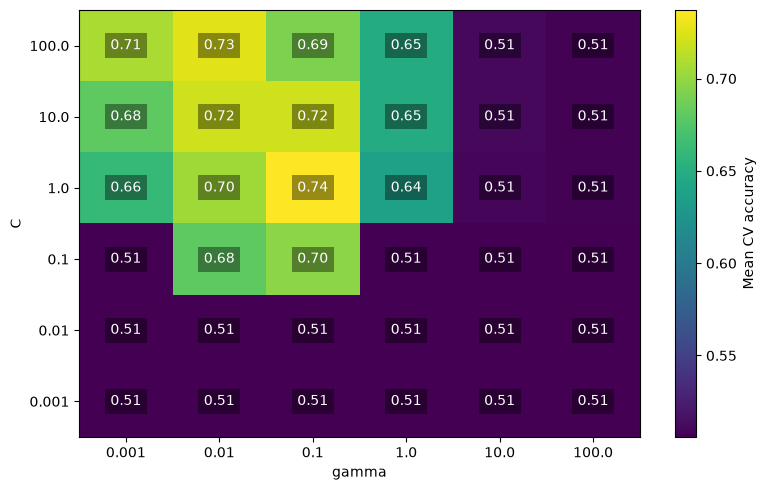

In [12]:
score_grid = grid_results.pivot(
    index="param_svc__C", columns="param_svc__gamma", values="mean_test_score",
).sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
heatmap = ax.imshow(score_grid.to_numpy(), cmap="viridis", aspect="auto", origin="lower")
ax.set_xticks(range(len(score_grid.columns)), labels=score_grid.columns)
ax.set_yticks(range(len(score_grid.index)), labels=score_grid.index)
ax.set_xlabel("gamma")
ax.set_ylabel("C")
for row in range(len(score_grid.index)):
    for col in range(len(score_grid.columns)):
        ax.text(col, row, f"{score_grid.iloc[row, col]:.2f}",
                ha="center", va="center", color="white",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none"))
fig.colorbar(heatmap, ax=ax, label="Mean CV accuracy")
fig.tight_layout();


Look for regions of useful performance, rather than just the single brightest cell. How much does a change in `gamma` matter at different values of `C`? The heatmap helps us see why tuning one hyperparameter while fixing the other can miss promising combinations.

If the best scores occur at a boundary, consider extending that boundary when computationally feasible and sensible for the model. If a promising region lies inside the grid, a finer search nearby may be useful. Neither strategy guarantees an improvement. Every such adjustment is another decision based on the same validation data, a point we will return to when discussing optimization bias.

::: {.callout-reflection}
Suppose every value of `C` performs poorly when `gamma` is very large. Would trying more closely spaced `C` values in that region be your first use of additional computation? Explain how the heatmap would guide your next search.
:::

### Tuning the representation and counting the cost

The number of grid configurations is the product of the numbers of choices. Adding six vocabulary sizes to our six-by-six model grid gives $6^3 = 216$ candidates and 1,080 cross-validation fits, plus the final refit. With five hyperparameters and ten values each, the cost becomes 100,000 candidates, or 500,000 cross-validation fits with five folds.

Changing `max_features` changes the representation available to the model, so it can affect which `C` and `gamma` settings work well. Searching these choices together is useful, but a full grid can become expensive. This motivates a search method with an explicit limit on the number of candidates.

::: {.callout-note collapse="true" title="Conditional grids"}
`GridSearchCV` also accepts a list of dictionaries. This is useful when a hyperparameter applies only to some configurations. For example, an RBF `SVC` uses both `C` and `gamma`, while a linear-kernel `SVC` uses `C` but ignores `gamma`. Separate dictionaries avoid repeating equivalent linear-kernel candidates for different values of `gamma`.
:::

## Randomized search

Instead of evaluating every combination, `RandomizedSearchCV` samples a specified number of candidates. Its `n_iter` argument controls that number, not a time limit. The actual running time also depends on the folds, dataset, and sampled settings.

We can first supply lists of possible values, just as we did for grid search. The following search samples 20 of the 216 possible configurations. With five folds and a final refit, it requires 101 pipeline fits.


In [13]:
search_values = {
    "columntransformer__countvectorizer__max_features": [100, 200, 400, 800, 1000, 2000],
    "svc__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1, 10, 100],
}
random_list_search = RandomizedSearchCV(
    svm_pipe, param_distributions=search_values, n_iter=20,
    cv=CV, scoring="accuracy", random_state=123, n_jobs=-1,
)
random_list_search.fit(X_train, y_train);


Setting `random_state` makes the sampled configurations reproducible. Increasing `n_iter` allows more exploration, but costs more fits and does not guarantee better performance on unseen data.

### Sampling from distributions

For a continuous hyperparameter, we need not limit ourselves to a short list. A **probability distribution** describes how likely values in different ranges are to be sampled. In hyperparameter search, it tells the search where to spend its trials. Equal-width ranges do not have to be equally likely: we can give some ranges more attention than others.

Two useful choices for this pipeline are:

- `loguniform(a, b)` for positive values spanning several orders of magnitude. Equal multiplicative intervals, such as 0.01–0.1 and 0.1–1, receive equal probability when they lie within the range.
- `randint(a, b)` for integer values from `a` up to, but excluding, `b`.

A uniform distribution over a very wide numerical interval puts most samples at its larger orders of magnitude. For example, uniform sampling between 0.001 and 100 puts about 90% of samples above 10. Log-uniform sampling gives the smaller orders of magnitude more attention.


::: {.callout-note collapse="true" title="Optional: What does sampling from a distribution look like?"}

Sampling means drawing values according to a distribution's probabilities. Imagine drawing 10,000 candidate values and counting how many fall into each interval. A **histogram** displays these counts as bars.

For **uniform sampling** between 0 and 5, equal-width intervals are equally likely. For example, a sample is just as likely to fall between 0 and 1 as between 4 and 5.

For **log-uniform sampling** between 0.001 and 100, equal multiplicative intervals are equally likely. Each tenfold interval—0.001–0.01, 0.01–0.1, and so on—has the same probability. The code below draws samples from each distribution; `.rvs` means drawing random values from the specified SciPy distribution.


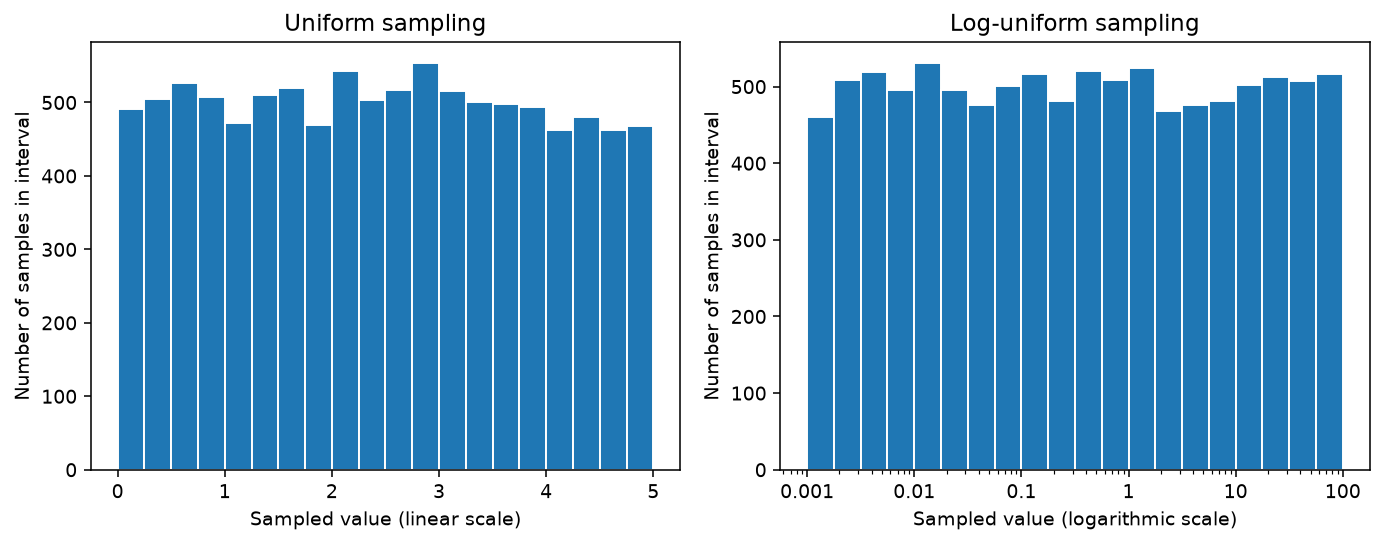

In [ ]:
# Use a local random generator so this illustration does not affect other examples.
distribution_rng = np.random.default_rng(123)
uniform_samples = distribution_rng.uniform(0, 5, size=10000)
loguniform_samples = loguniform.rvs(
    1e-3, 1e2, size=10000, random_state=distribution_rng,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(uniform_samples, bins=np.linspace(0, 5, 21), edgecolor="white")
axes[0].set(title="Uniform sampling", xlabel="Sampled value (linear scale)",
            ylabel="Number of samples in interval")
axes[1].hist(loguniform_samples, bins=np.logspace(-3, 2, 21), edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xticks([0.001, 0.01, 0.1, 1, 10, 100],
                  labels=["0.001", "0.01", "0.1", "1", "10", "100"])
axes[1].set(title="Log-uniform sampling", xlabel="Sampled value (logarithmic scale)",
            ylabel="Number of samples in interval")
fig.tight_layout();


The bars are roughly level in both plots, but **the horizontal scales and intervals differ**. The left plot uses equal-width bins on a linear axis. The right uses bins with equal multiplicative ratios on a logarithmic axis: the interval from 1 to 10 occupies the same horizontal distance as 0.01 to 0.1. On a linear axis, the log-uniform samples would look concentrated near the small values. The slight differences in bar heights come from random sampling.

**Pause and think:** If `C` could plausibly be anywhere between 0.001 and 100, would uniform or log-uniform sampling give the smaller orders of magnitude more attention?

Log-uniform sampling would. It assigns the same probability to each tenfold interval in this range, whereas uniform sampling puts about 90% of samples between 10 and 100. The distribution therefore changes which parts of the search space receive more trials; neither choice guarantees good hyperparameters.
:::


In [14]:
param_distributions = {
    "columntransformer__countvectorizer__max_features": randint(100, 2001),
    "svc__C": loguniform(1e-3, 1e2),
    "svc__gamma": loguniform(1e-3, 1e2),
}
random_dist_search = RandomizedSearchCV(
    svm_pipe, param_distributions=param_distributions, n_iter=20,
    cv=CV, scoring="accuracy", random_state=123, n_jobs=-1,
)
random_dist_search.fit(X_train, y_train);


These distributions are choices about where to spend computation; they are not learned from the data. Their ranges still need to be sensible. For example, increasing `max_features` beyond the number of available vocabulary terms will not produce additional features.

### Why can random search use a budget more effectively?

Suppose performance depends strongly on one hyperparameter and only weakly on another. A three-by-three grid evaluates nine candidates but tries only three distinct values of the important hyperparameter. A random search over continuous ranges can try nine distinct values of it with the same number of evaluations.


![Grid and random search with nine evaluations each. Random search explores more distinct values along the important dimension.](img/randomsearch_bergstra.png)

Source: Bergstra and Bengio, [Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/v13/bergstra12a.html), 2012.

In this illustration, the horizontal dimension matters more than the vertical one. The grid spends several evaluations varying only the less important dimension. We generally do not know in advance which dimensions matter most, which makes random search attractive for larger spaces.

Random search is not inherently faster per fit and does not always find a better candidate. A small grid is useful when we have a few specific combinations to compare or want a heatmap. Random search lets us explore a larger space while controlling the number of evaluations.

::: {.callout-note collapse="true" title="Optional: searches that adapt as they run"}
Successive halving starts by evaluating many candidates with a small resource allocation, such as fewer training examples, and gives more resources to promising candidates. This can save computation, although early performance with limited resources may not reflect performance with the full budget.

Model-based methods, including Bayesian optimization, use the outcomes of earlier trials to guide later choices. These methods can be useful when individual fits are expensive. They still require a suitable search space and an evaluation procedure that protects held-out data.
:::

## Optimization bias and final evaluation

We have now compared several searches using the same training set. How should we choose the final pipeline? We can compare their selected mean cross-validation accuracies, but we must be careful about what the winning score means.


In [15]:
searches = {
    "Grid": grid_search,
    "Random (lists)": random_list_search,
    "Random (distributions)": random_dist_search,
}
search_comparison = pd.DataFrame([
    {"search": name, "best_mean_cv_accuracy": search.best_score_,
     "candidates": len(search.cv_results_["params"])}
    for name, search in searches.items()
]).set_index("search")
search_comparison


,best_mean_cv_accuracy,candidates
search,,
Grid,0.737121,36
Random (lists),0.737121,20
Random (distributions),0.745178,20


This table compares the searches we ran, not the search algorithms in general: their spaces and budgets differ. To finish this example, we will choose the pipeline with the highest mean cross-validation accuracy among these searches.

### Why the winning score can be optimistic

A validation score depends on both a model's predictive ability and the particular examples used to evaluate it. When we select the highest score among many candidates, we may select a candidate that benefited from favourable evaluation noise. Its score can overstate its performance on new data. This selection effect is called **optimization bias**, or **overfitting the validation set**.

This differs from fitting a model too closely to its training examples. Even when every pipeline obeys the Golden Rule within each fold, repeatedly using the validation scores to make choices can overfit those scores. Cross-validation reduces dependence on one split, but it does not remove the effect of selecting a winner.

### A random-answer example

Imagine answering a ten-question multiple-choice quiz by guessing among four options. One randomly completed answer sheet has an expected accuracy of 25%. Now generate 100 answer sheets and keep whichever scores highest on those same ten questions. The selected sheet will usually score much better than 25%, even though no knowledge was involved.

On new questions, random guessing still has an expected accuracy of 25%. The improvement came from selection on the original questions. In the analogy, the questions play the role of validation examples, and the answer sheets play the role of candidate models.

The code below computes the expected winning score for different numbers of answer sheets, comparing quizzes with 10 and 100 questions. It avoids a slow simulation by using the probabilities for the number of correct guesses.


In [16]:
# Adapted from the random-answer example attributed to Rodolfo Lourenzutti
# in the original lecture notes.
number_sheets = np.array([1, 2, 10, 100, 1000, 10000])
expected_best = {}
for number_questions in [10, 100]:
    # P(one sheet has at most k correct answers), for k = 0, ..., q - 1.
    cdf = binom.cdf(np.arange(number_questions), number_questions, 0.25)
    # P(best of m sheets exceeds k) = 1 - P(all m sheets score at most k).
    expected_best[f"{number_questions} questions"] = [
        np.sum(1 - cdf ** m) / number_questions for m in number_sheets
    ]

bias_table = pd.DataFrame(expected_best, index=number_sheets)
bias_table.index.name = "Number of answer sheets tried"
bias_table.round(3)


,10 questions,100 questions
Number of answer sheets tried,,
1,0.250,0.250
2,0.326,0.274
10,0.470,0.318
100,0.620,0.362
1000,0.734,0.397
10000,0.825,0.426


The expected winning score rises as we try more sheets. With more questions, chance fluctuations are smaller, and the selection effect is less pronounced. You do not need the probability calculation to use the lesson: searching many possibilities on a small validation set makes an unusually high score easier to obtain by chance.

Real models are not independent random answer sheets. Similar hyperparameter settings often make similar predictions, so this example does not quantify the bias in our Spotify search. It isolates the reason selection can produce optimism even without a real improvement in predictive ability.

The same issue applies to manual decisions: trying new features, changing preprocessing, comparing model families, and refining a search range all use validation information. The number of candidates in one `GridSearchCV` call is only part of the model-selection process.

### Putting the workflow together: final evaluation

We began with a loop that compared tree depths and then refitted the selected pipeline. We now have the same workflow for a complete preprocessing-and-SVM pipeline: define candidate settings, compare them using cross-validation, select a configuration, and refit on all the training data. Both preprocessing and model fitting are part of that refit. The final step is to evaluate the selected pipeline on data that did not guide any of these choices.

The held-out test set gives us an evaluation that was not used to make these choices. We now select the winning search using only its cross-validation score and evaluate its already-refitted pipeline once.


In [17]:
selected_name = max(searches, key=lambda name: searches[name].best_score_)
selected_search = searches[selected_name]
final_test_accuracy = selected_search.score(X_test, y_test)
pd.Series({
    "selected_search": selected_name,
    "selected_mean_cv_accuracy": selected_search.best_score_,
    "final_test_accuracy": final_test_accuracy,
})


selected_search              Random (distributions)
selected_mean_cv_accuracy                  0.745178
final_test_accuracy                         0.75495
dtype: object

These two scores need not match. The cross-validation score was used for selection and came from models fitted on only part of the training set. The test score evaluates the refitted pipeline on a different sample. Sampling variation can make the test score either higher or lower; a gap alone does not measure optimization bias.

An untouched test set does not guarantee a precise estimate. Its size and how well it represents the intended prediction setting still matter. More representative data can improve evaluation precision and learning, but simply having more rows does not guarantee a better model.

::: {.callout-important title="What if the test score is disappointing?"}
Do not tune against the test score and then report it as an independent final evaluation. Investigate the workflow and report the result honestly. If you use the test results to guide further model development, that set has become part of model selection; a fresh held-out evaluation is needed for the revised model.
:::

::: {.callout-note collapse="true" title="Optional: nested cross-validation"}
Another evaluation design places the entire hyperparameter search inside an outer cross-validation loop. Each outer training portion runs its own inner search; its outer held-out portion evaluates the selected pipeline. This is called **nested cross-validation**. It evaluates the selection procedure across multiple splits, at a substantial computational cost. The outer scores must also be protected from repeated tuning decisions.
:::

## Exercises

### Exercise 6.1: Budget a search

You want to tune three hyperparameters with 4, 5, and 6 candidate values, using five-fold cross-validation. How many pipeline fits does grid search require, including the default final refit? How many does random search require with `n_iter=20`? What do you give up by using the smaller search?

::: {.callout-tip collapse="true" title="Solution"}
Grid search evaluates $4 \times 5 \times 6 = 120$ candidates, requiring $120 \times 5 + 1 = 601$ fits. Random search requires $20 \times 5 + 1 = 101$ fits. The random search leaves many combinations unevaluated and may miss a useful one; neither search guarantees the best settings beyond its evaluated candidates or on future data.
:::

### Exercise 6.2: Decide what to try next

Your best mean validation accuracy occurs at `C=100`, the largest value in your grid. A colleague concludes that the optimal value is 100. What does the result actually establish? Suggest a next step that preserves the test set's role.

::: {.callout-tip collapse="true" title="Solution"}
It establishes that this candidate has the highest mean validation score among those evaluated, possibly tied with others. Inspect neighbouring scores and consider extending the range above 100 using training-set cross-validation. The boundary result does not prove that a larger value will help. Keep the test set out of this decision.
:::

### Exercise 6.3: Find the evaluation problems

A student fits `CountVectorizer` to all song titles before splitting the data. They then search 200 SVM settings and report the winning `mean_test_score` from `cv_results_` as their final test accuracy. Identify two problems and explain how to fix them.

::: {.callout-tip collapse="true" title="Solution"}
The vocabulary was learned using data that should have been held out. Split the raw data first and place the vectorizer inside the pipeline searched by cross-validation. Also, `mean_test_score` is a cross-validation score used for selection, not an independent test score. Evaluate the selected, refitted pipeline on an untouched test set after model selection is complete.
:::

### Exercise 6.4: Would you trust the reported accuracy?

Adapted from a question in Mark Schmidt's notes.

A colleague receives a small subset of a dataset, uses 96% of it for training and 4% for validation, and tries many hyperparameter settings. The winning validation accuracy is 97%. Should you expect similar accuracy on the remaining data? Explain what makes this estimate uncertain and what evidence would help.

::: {.callout-tip collapse="true" title="Solution"}
The reported score is insufficient evidence. A small validation set gives a noisy estimate, and selecting the best among many settings can make it optimistic. The subset may also differ from the remaining data. An evaluation on sufficiently large, representative data that was not used for selection would provide more useful evidence. We cannot infer the actual accuracy from the information given.
:::

### Exercise 6.5: Respond to a disappointing test score

After evaluating on the test set, you change the vocabulary size and rerun the search because the result was disappointing. The revised model scores better on that same test set. Can you report this as an independent final evaluation? Why or why not?

::: {.callout-tip collapse="true" title="Solution"}
No. The first test result influenced a modelling decision, so the test set is now part of development. Report that reuse transparently and obtain a fresh held-out evaluation for the revised model. A better score on the reused set is not by itself evidence of the same improvement on new data.
:::

## Summary

- Hyperparameter search compares models fitted under different settings. Search the complete pipeline so preprocessing is learned separately within each fold.
- Grid search evaluates every specified combination; randomized search evaluates a chosen number of sampled configurations.
- Search ranges matter. Use model knowledge, broad initial ranges, and validation results to decide where further computation is useful.
- `best_score_` is a score used for selection. With the default refitting behaviour, `best_estimator_` is the selected pipeline fitted on all the training data.
- Selecting the best validation result can produce optimization bias. Protect the test set throughout model development and use it for the final evaluation.

::: {.callout-tip title="Further reading"}
The scikit-learn [hyperparameter-tuning guide](https://scikit-learn.org/stable/modules/grid_search.html) provides additional examples and search strategies. The API references for [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) and [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) describe their arguments and fitted attributes.
:::
